In [53]:
from pathlib import Path

Dataset_dir = Path("../data/mvtec_anomaly_detection/metal_nut")

print("Dataset_dir: ", Dataset_dir.exists())
train_good = list((Dataset_dir/"train"/"good").glob("*.png"))
print(f"Training data set image count is: {len(train_good)}")

folders = ["bent", "color", "flip" ,"good", "scratch"]
for f in folders:
    test = list((Dataset_dir/"test"/f).glob("*.png"))
    print(f"Test {f:8}: {len(test)}")

Dataset_dir:  True
Training data set image count is: 220
Test bent    : 25
Test color   : 22
Test flip    : 23
Test good    : 22
Test scratch : 23


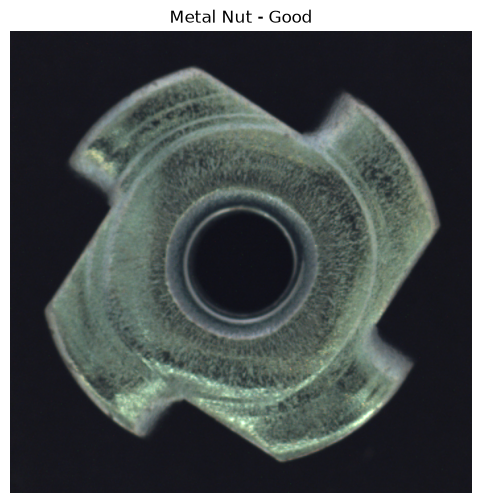

In [54]:
from PIL import Image
import matplotlib.pyplot as plt

good_image = Image.open(train_good[0])
plt.figure(figsize= (6,6))
plt.axis("off")
plt.imshow(good_image)
plt.title("Metal Nut - Good")
plt.show()

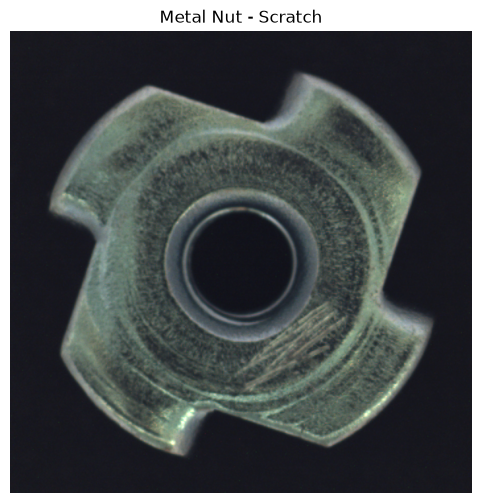

In [55]:
scratch_images = list((Dataset_dir/"test"/"scratch").glob("*.png"))
first_image = Image.open(scratch_images[0])

plt.figure(figsize=(6,6))
plt.imshow(first_image)
plt.axis("off")
plt.title("Metal Nut - Scratch")
plt.show()

In [56]:
from anomalib.models import Patchcore
model = Patchcore()
print(model)

Patchcore(
  (pre_processor): PreProcessor(
    (transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=True)
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
    (export_transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=False)
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
  )
  (post_processor): PostProcessor(
    (_image_threshold_metric): F1AdaptiveThreshold()
    (_pixel_threshold_metric): F1AdaptiveThreshold()
    (_image_min_max_metric): MinMax()
    (_pixel_min_max_metric): MinMax()
  )
  (evaluator): Evaluator(
    (val_metrics): ModuleList()
    (test_metrics): ModuleList(
      (0): AUROC()
      (1): F1Score()
      (2): AUROC()
      (3): F1Score()
    )
  )
  (model): PatchcoreModel(
    (feature_extractor): TimmFeatureExtractor(
      (feature_extractor): FeatureListNet

In [57]:
from anomalib.data import MVTecAD

datamodule = MVTecAD(
    root="../data/mvtec_anomaly_detection",
    category="metal_nut",
    train_batch_size=32,
    eval_batch_size=32,
    num_workers=0,
)

datamodule.setup()

train_loader = datamodule.train_dataloader()

print("num_workers:", train_loader.num_workers)
print("batch_size:", train_loader.batch_size)

num_workers: 0
batch_size: 32


In [58]:
datamodule.setup()

In [59]:
print("Train dataloader:", datamodule.train_dataloader())
print("Test dataloader:", datamodule.test_dataloader())

Train dataloader: <torch.utils.data.dataloader.DataLoader object at 0x00000270C4640090>
Test dataloader: <torch.utils.data.dataloader.DataLoader object at 0x00000270C4640090>


In [60]:
batch = next(iter(train_loader))

print("Batch loaded successfully!")
print("Image shape:", batch.image.shape)

Batch loaded successfully!
Image shape: torch.Size([32, 3, 700, 700])


In [61]:
print("Image shape:", batch.image.shape)
print("Ground-truth label shape:", batch.gt_label.shape)
print("Ground-truth labels:", batch.gt_label)

Image shape: torch.Size([32, 3, 700, 700])
Ground-truth label shape: torch.Size([32])
Ground-truth labels: tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False])


In [62]:
print("First image:")
print(batch.image_path[0])

First image:
C:\Users\Abhiram\OneDrive\Desktop\My projects\Kweka AI Solutions\Anomaly_Detection\Anomaly_Detector\backend\data\mvtec_anomaly_detection\metal_nut/train/good/191.png


In [63]:
import os
import torch

os.environ["TQDM_DISABLE"] = "1"
torch.set_float32_matmul_precision("high")

In [64]:
import os

os.environ["TQDM_DISABLE"] = "1"
os.environ["LIGHTNING_PROGRESS_BAR"] = "0"

In [ ]:
from anomalib.models import Patchcore
from anomalib.engine import Engine

model = Patchcore(
    backbone = "wide_resnet50_2",
    layers = ["layer2", "layer3"],
    pre_trained = True,
    coreset_sampling_ratio = 0.1,
    num_neighbors = 9,
)

engine = Engine(
    max_epochs = 1,
    accelerator = "auto",
    devices = 1,
    enable_progress_bar = False,
)

print("Patchcore Created Successfully")
print("Engine created Successfully")

Patchcore Created Successfully
Engine created Successfully


In [66]:
engine.fit(
    model=model,
    datamodule=datamodule,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Abhiram\OneDrive\Desktop\My projects\Kweka AI Solutions\Anomaly_Detection\Anomaly_Detector\backend\venv\Lib\site-packages\lightning\pytorch\core\optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │ 24.9 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 24.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.9 M                                                                                               
Total estimated model params size (MB): 99.450                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 174                                                                                          
Total FLOPs: 0

Output()

c:\Users\Abhiram\OneDrive\Desktop\My projects\Kweka AI Solutions\Anomaly_Detection\Anomaly_Detector\backend\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Abhiram\OneDrive\Desktop\My projects\Kweka AI Solutions\Anomaly_Detection\Anomaly_Detector\backend\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\Abhiram\OneDrive\Desktop\My projects\Kweka AI Solutions\Anomaly_Detection\Anomaly_Detector\backend\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers`

Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting Coreset Indices.:   0%|          | 0/22527 [00:00<?, ?it/s]
Selecting 

RecursionError: maximum recursion depth exceeded